# Differential Logic Part 2: Continuous Relaxition

blog post: https://fualsan.github.io/posts/differential-logic-part-2/

In [1]:
import jax
import jax.numpy as jnp

import matplotlib.pyplot as plt

In [2]:
NUM_SAMPLES = 100
x1 = jnp.linspace(10.0, 50.0, NUM_SAMPLES)

## Logistic Sigmoid 

In [3]:
def sigmoid(x):
    return 1.0 / (1.0 + jnp.power(jnp.e, -x))

def logistic_sigmoid_relaxation_gt(x, condition, steepness):
    """
    True for points satisfying: x > condition
    """
    return sigmoid(steepness*(x-condition))

def logistic_sigmoid_relaxation_lt(x, condition, steepness):
    """
    True for points satisfying x < condition
    """
    return sigmoid(steepness*(condition-x))

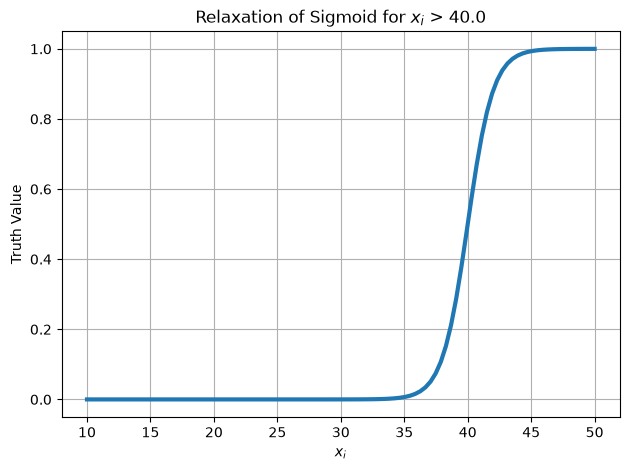

In [4]:
CONDITION = 40.0
STEEPNESS = 1.0

# GREATER THAN
x_res = logistic_sigmoid_relaxation_gt(x1, CONDITION, STEEPNESS)

plt.plot(x1, x_res, linewidth=3.0)
plt.title(f'Relaxation of Sigmoid for {r"$x_i$"} > {CONDITION}')
plt.xlabel(r"$x_i$")
plt.ylabel('Truth Value')
plt.grid('on')
plt.tight_layout()
plt.savefig(
    'logistic_sigmoid_relaxation_gt.png',
    bbox_inches='tight', 
    dpi=300
)

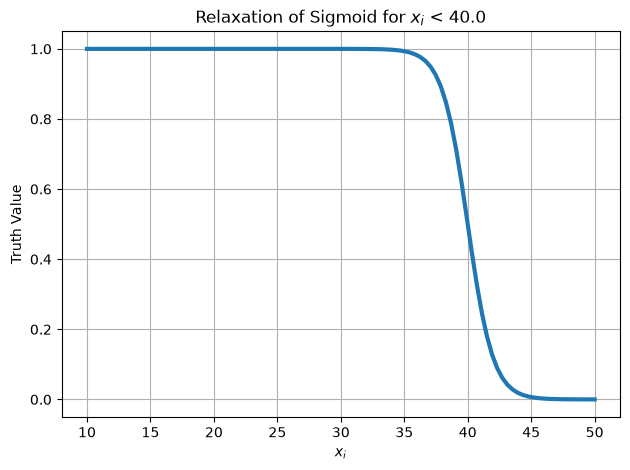

In [5]:
CONDITION = 40.0
STEEPNESS = 1.0

# LESS THAN
x_res = logistic_sigmoid_relaxation_lt(x1, CONDITION, STEEPNESS)

plt.plot(x1, x_res, linewidth=3.0)
plt.title(f'Relaxation of Sigmoid for {r"$x_i$"} < {CONDITION}')
plt.xlabel(r"$x_i$")
plt.ylabel('Truth Value')
plt.grid('on')
plt.tight_layout()
plt.savefig(
    'logistic_sigmoid_relaxation_lt.png',
    bbox_inches='tight', 
    dpi=300
)

### Higher Steepness

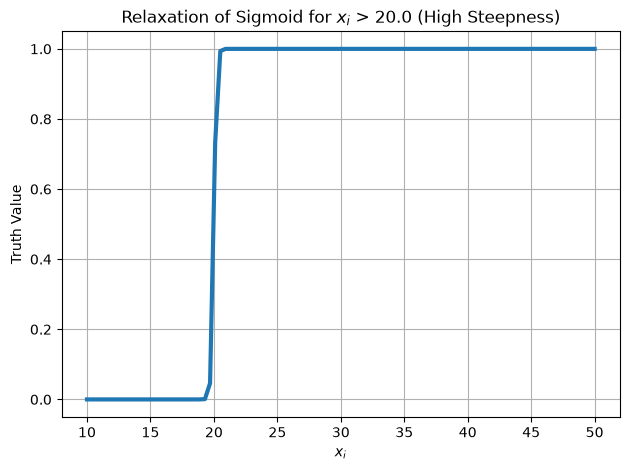

In [6]:
CONDITION = 20.0
STEEPNESS = 10.0

# GREATER THAN
x_res = logistic_sigmoid_relaxation_gt(x1, CONDITION, STEEPNESS)

plt.plot(x1, x_res, linewidth=3.0)
plt.title(f'Relaxation of Sigmoid for {r"$x_i$"} > {CONDITION} (High Steepness)')
plt.xlabel(r"$x_i$")
plt.ylabel('Truth Value')
plt.grid('on')
plt.tight_layout()
plt.savefig(
    'logistic_sigmoid_relaxation_gt_higher_steepness.png',
    bbox_inches='tight', 
    dpi=300
)

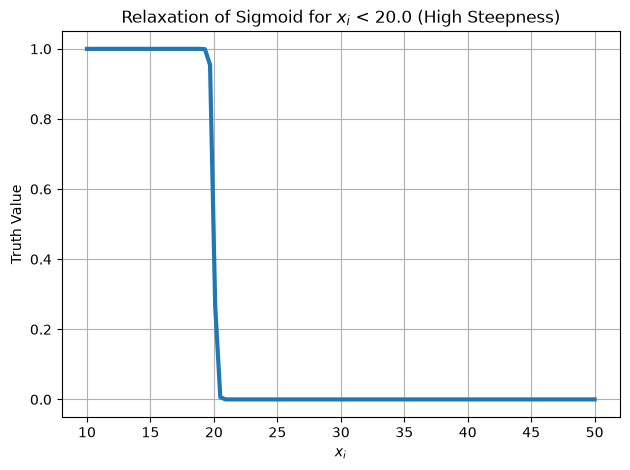

In [7]:
CONDITION = 20.0
STEEPNESS = 10.0

# LESS THAN
x_res = logistic_sigmoid_relaxation_lt(x1, CONDITION, STEEPNESS)

plt.plot(x1, x_res, linewidth=3.0)
plt.title(f'Relaxation of Sigmoid for {r"$x_i$"} < {CONDITION} (High Steepness)')
plt.xlabel(r"$x_i$")
plt.ylabel('Truth Value')
plt.grid('on')
plt.tight_layout()
plt.savefig(
    'logistic_sigmoid_relaxation_lt_higher_steepness.png',
    bbox_inches='tight', 
    dpi=300
)

## Interval Relaxation

In [8]:
def logistic_sigmoid_relaxation_interval_sub(x, condition_a, condition_b, steepness):
    """
    True for points satisfying condition_a < x < condition_b
    """
    return sigmoid(steepness * (x - condition_a)) - sigmoid(steepness * (x - condition_b))

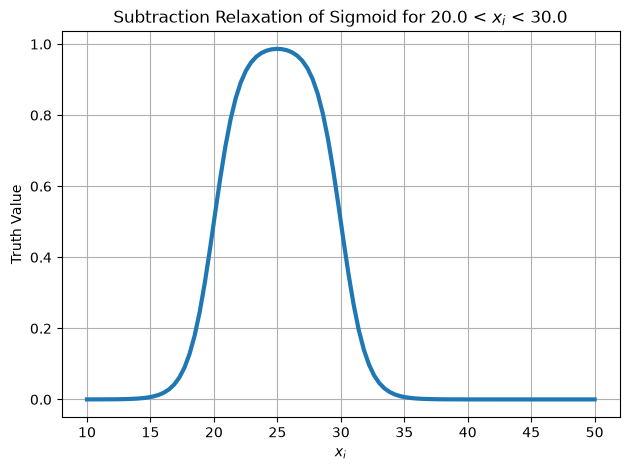

In [9]:
CONDITION_L = 20.0
CONDITION_H = 30.0
STEEPNESS = 1.0
x_res = logistic_sigmoid_relaxation_interval_sub(x1, CONDITION_L, CONDITION_H, STEEPNESS)

plt.plot(x1, x_res, linewidth=3.0)
plt.title(f'Subtraction Relaxation of Sigmoid for {CONDITION_L} < {r"$x_i$"} < {CONDITION_H}')
plt.xlabel(r"$x_i$")
plt.ylabel('Truth Value')
plt.grid('on')
plt.tight_layout()
plt.savefig(
    'logistic_sigmoid_relaxation_interval_sub.png',
    bbox_inches='tight', 
    dpi=300
)

In [10]:
def logistic_sigmoid_relaxation_prod(x, condition_a, condition_b, steepness):
    """
    True for points satisfying condition_a < x < condition_b
    """
    return sigmoid(steepness * (x - condition_a)) * sigmoid(steepness * (condition_b - x))

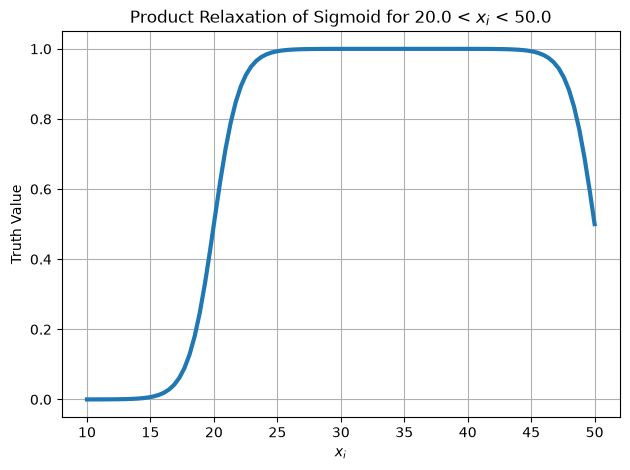

In [11]:
CONDITION_L = 20.0
CONDITION_H = 50.0
STEEPNESS = 1.0
x_res = logistic_sigmoid_relaxation_prod(x1, CONDITION_L, CONDITION_H, STEEPNESS)

plt.plot(x1, x_res, linewidth=3.0)
plt.title(f'Product Relaxation of Sigmoid for {CONDITION_L} < {r"$x_i$"} < {CONDITION_H}')
plt.xlabel(r"$x_i$")
plt.ylabel('Truth Value')
plt.grid('on')
plt.tight_layout()
plt.savefig(
    'logistic_sigmoid_relaxation_prod.png',
    bbox_inches='tight', 
    dpi=300
)

## Gradients Per Input

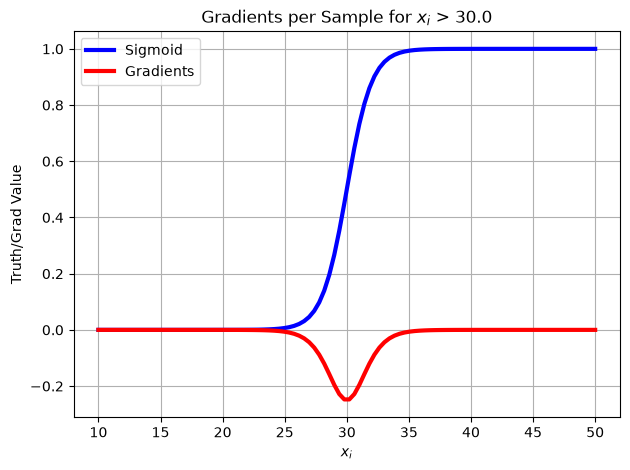

In [12]:
CONDITION = 30.0
STEEPNESS = 1.0
x_res = logistic_sigmoid_relaxation_gt(x1, CONDITION, STEEPNESS)

grad_fn = jax.grad(logistic_sigmoid_relaxation_gt, argnums=(1,))
grad_fn_per_sample = jax.vmap(grad_fn, in_axes=(0, 0, 0))

c_vmap = jnp.full_like(x_res, fill_value=CONDITION)
s_vmap = jnp.full_like(x_res, fill_value=STEEPNESS)
grad_c_per_sample = grad_fn_per_sample(x1, c_vmap, s_vmap)[0]

plt.plot(x1, x_res, linewidth=3.0, label='Sigmoid', c='b')
plt.plot(x1, grad_c_per_sample, linewidth=3.0, label='Gradients', c='r')
plt.title(f'Gradients per Sample for {r"$x_i$"} > {CONDITION}')
plt.xlabel(r"$x_i$")
plt.ylabel('Truth/Grad Value')
plt.grid('on')
plt.legend()
plt.tight_layout()
plt.savefig(
    'grad_fn_per_sample.png',
    bbox_inches='tight', 
    dpi=300
)

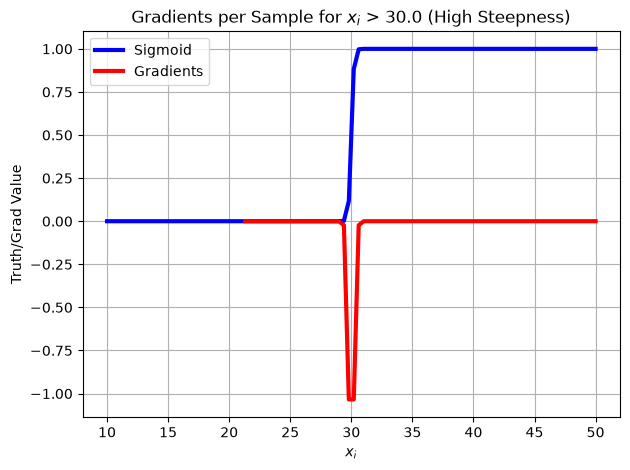

In [13]:
CONDITION = 30.0
STEEPNESS = 10.0
x_res = logistic_sigmoid_relaxation_gt(x1, CONDITION, STEEPNESS)

grad_fn = jax.grad(logistic_sigmoid_relaxation_gt, argnums=(1,))
grad_fn_per_sample = jax.vmap(grad_fn, in_axes=(0, 0, 0))

c_vmap = jnp.full_like(x_res, fill_value=CONDITION)
s_vmap = jnp.full_like(x_res, fill_value=STEEPNESS)
grad_c_per_sample = grad_fn_per_sample(x1, c_vmap, s_vmap)[0]

plt.plot(x1, x_res, linewidth=3.0, label='Sigmoid', c='b')
plt.plot(x1, grad_c_per_sample, linewidth=3.0, label='Gradients', c='r')
plt.title(f'Gradients per Sample for {r"$x_i$"} > {CONDITION} (High Steepness)')
plt.xlabel(r"$x_i$")
plt.ylabel('Truth/Grad Value')
plt.grid('on')
plt.legend()
plt.tight_layout()
plt.savefig(
    'grad_fn_per_sample_high_steepness.png',
    bbox_inches='tight',
    dpi=300
)

## Differential Optimization of Continuous Relaxation
* Sigmoid output is mostly flat for wide range of values
* This is problematic for differential optimization
    * (Gradients for zero for most of the range)
    * (Zero gradients are not useful for updating and training)
* Hence we use smaller ranges to keep gradients flowing
* Thus, we scale input values $x_i$ into the range $[-4.0, 4.0]$ for efficiency

In [14]:
from sklearn.preprocessing import MinMaxScaler

In [15]:
x_data = jnp.array([
    42.0, 7.0, 89.0, 13.0, 56.0, 3.0, 74.0, 91.0, 28.0, 65.0,
    17.0, 100.0, 34.0, 82.0, 5.0, 49.0, 76.0, 21.0, 68.0, 11.0,
    93.0, 37.0, 60.0, 1.0, 84.0, 25.0, 53.0, 72.0, 16.0, 98.0
])

# INITIALIZE THE CONDITION AS THE MEAN OF THE DATASET
x_condition = jnp.mean(x_data)
print(f'Initial condition: {x_condition.item():2.4f}')

# SET TRUE THE FOR TARGET OR ABOVE
TARGET_CONDITION = 20.0
x_target = (x_data>TARGET_CONDITION).astype(jnp.float32)
print(x_target)

Initial condition: 49.0000
[1. 0. 1. 0. 1. 0. 1. 1. 1. 1. 0. 1. 1. 1. 0. 1. 1. 1. 1. 0. 1. 1. 1. 0.
 1. 1. 1. 1. 0. 1.]


In [16]:
scaler = MinMaxScaler(feature_range=(-4.0, 4.0))

In [17]:
x_data_scaled = scaler.fit_transform(x_data.reshape(-1, 1).copy()).ravel()
print(x_data_scaled)

[-0.68686867 -3.5151515   3.1111112  -3.030303    0.44444418 -3.838384
  1.8989897   3.272727   -1.818182    1.1717172  -2.7070708   3.9999995
 -1.3333335   2.5454545  -3.6767678  -0.12121224  2.060606   -2.3838384
  1.4141412  -3.1919193   3.4343433  -1.0909092   0.76767683 -4.
  2.7070708  -2.0606062   0.20202017  1.7373738  -2.787879    3.8383837 ]


In [18]:
x_condition_scaled = scaler.transform(x_condition.reshape(-1, 1).copy()).ravel()
print(x_condition_scaled)

[-0.12121201]


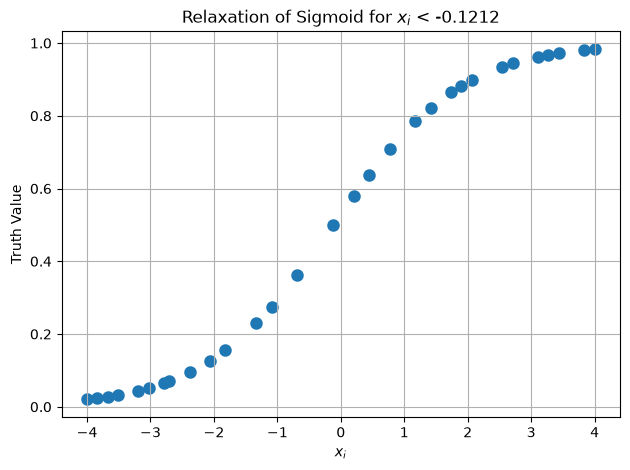

In [19]:
STEEPNESS = 1.0

# GRADS ARE MUCH STABLE HERE
plt.scatter(
    x_data_scaled, 
    logistic_sigmoid_relaxation_gt(x_data_scaled, x_condition_scaled, STEEPNESS),
    linewidth=3.0
)
plt.title(f'Relaxation of Sigmoid for {r"$x_i$"} < {x_condition_scaled.item():2.4f}')
plt.xlabel(r"$x_i$")
plt.ylabel('Truth Value')
plt.grid('on')
plt.tight_layout()
plt.savefig(
    'logistic_sigmoid_relaxation_gt_scaled_input.png',
    bbox_inches='tight',
    dpi=300
)

### Training Loop

In [20]:
from functools import partial

from triangular_norms import diff_equivalence

In [21]:
diff_eq_prod_sum = partial(diff_equivalence, name_tnorm='product', name_tconorm='probabilistic_sum')

def final_truth(x, c, s, target):
    pred = logistic_sigmoid_relaxation_gt(x, c, s)
    truth_i = diff_eq_prod_sum(pred, target)
    return jnp.mean(truth_i)

grad_fn = jax.value_and_grad(final_truth, argnums=(1,))

STEEPNESS = 1.0
LEARNING_RATE = 1.0
NUM_EPOCHS = 140

for epoch in range(1, NUM_EPOCHS+1):

    final_truth, grads = grad_fn(x_data_scaled, x_condition_scaled, STEEPNESS, x_target)

    # PUSH CONDITON TOWARDS TO MAX TRUTH POINT
    x_condition_scaled = x_condition_scaled + LEARNING_RATE*grads[0]

    acc = 100.0 * (jnp.sum((x_data_scaled > x_condition_scaled).astype(jnp.int32) == x_target) / len(x_target))

    if epoch % 20 == 0:
        print(f'Epoch: {epoch:>3}, Truth: {final_truth.item():2.2f} Accuracy: {acc.item():2.2f}%')

Epoch:  20, Truth: 0.82 Accuracy: 90.00%
Epoch:  40, Truth: 0.84 Accuracy: 93.33%
Epoch:  60, Truth: 0.85 Accuracy: 96.67%
Epoch:  80, Truth: 0.85 Accuracy: 96.67%
Epoch: 100, Truth: 0.85 Accuracy: 96.67%
Epoch: 120, Truth: 0.85 Accuracy: 96.67%
Epoch: 140, Truth: 0.85 Accuracy: 100.00%


In [22]:
x_final_condition_scaled = x_condition_scaled.copy()
# RESCALE BACK TO ORIGINAL
x_final_condition = scaler.inverse_transform(x_final_condition_scaled.reshape(-1, 1)).ravel()

print(f'Target condition: {TARGET_CONDITION:2.2f}')
print(f'Learned condition: {x_final_condition.item():2.2f}')

Target condition: 20.00
Learned condition: 20.98


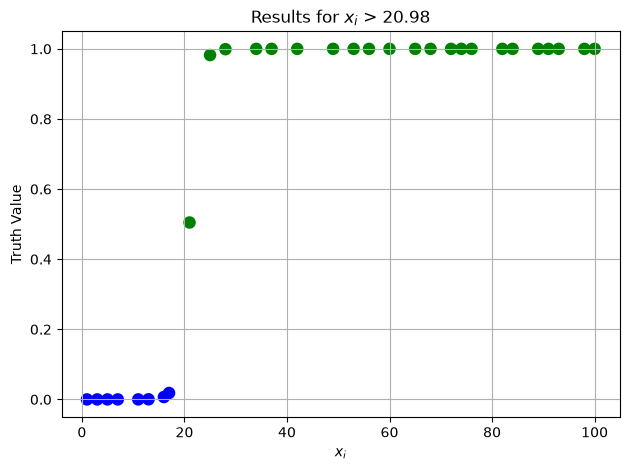

In [23]:
colors = ['blue' if l == 0 else 'green' for l in x_target]

plt.scatter(
    x_data, 
    logistic_sigmoid_relaxation_gt(x_data, x_final_condition, STEEPNESS), 
    c=colors,
    linewidth=3.0
)
plt.title(f'Results for {r"$x_i$"} > {x_final_condition.item():2.2f}')
plt.xlabel(r"$x_i$")
plt.ylabel('Truth Value')
plt.grid('on')
plt.tight_layout()
plt.savefig(
    'logistic_sigmoid_relaxation_gt_training_results.png',
    bbox_inches='tight',
    dpi=300
)